# Limpieza y Automatización de Datos de Gastos para una Pyme

**Problema de negocio:** en muchas pymes, el registro de gastos se lleva en planillas Excel alimentadas manualmente (o exportadas desde distintos sistemas: bancos, cotizaciones, boletas). El resultado típico son formatos inconsistentes de fecha y montos, categorías escritas de formas distintas, proveedores duplicados con nombres variables, y filas duplicadas o vacías. Esto hace que cada cierre mensual requiera horas de limpieza manual antes de poder analizar algo.

**Objetivo:** construir un pipeline de limpieza reutilizable que tome cualquier planilla de gastos con esta estructura y entregue datos estandarizados, listos para análisis o carga a un dashboard — reduciendo un proceso de horas a segundos.

**Enfoque:** se diagnostican los problemas de calidad de datos, se resuelven de forma sistemática (no ad-hoc) mediante funciones documentadas, y se empaqueta todo en un script (`limpiar_gastos.py`) que puede ejecutarse desde línea de comandos sobre cualquier planilla nueva del cliente.

**Resultado:** de 434 filas con datos inconsistentes se pasa a 423 filas limpias y estandarizadas, con un reporte automático de todos los problemas corregidos — trazabilidad que cualquier cliente puede revisar.

**Stack:** Python · pandas · numpy · openpyxl

---


## 1) Carga de datos y diagnóstico inicial

Se carga la planilla tal como la entregaría el cliente: sin ningún preprocesamiento previo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_crudo = pd.read_excel('gastos_pyme_sucio.xlsx')
print(f'Dimensiones: {df_crudo.shape[0]} filas x {df_crudo.shape[1]} columnas')
df_crudo.head(8)


Dimensiones: 434 filas x 9 columnas


### 1.1) Tipos de datos

Todas las columnas llegan como texto (`object`), incluso las que deberían ser numéricas o fechas — señal típica de una exportación sin control de formato.

In [2]:
df_crudo.dtypes


### 1.2) Valores nulos por columna

In [3]:
nulos = df_crudo.isnull().sum()
print(nulos[nulos > 0])


ID_Gasto            2
Fecha               2
Categoria          11
Proveedor          11
Monto               2
Metodo_Pago        11
Descripcion       172
Numero_Factura     50
Aprobado            2
dtype: int64


### 1.3) Filas duplicadas

In [4]:
print('Filas completamente duplicadas:', df_crudo.duplicated().sum())
print('Filas completamente vacías:', df_crudo.isnull().all(axis=1).sum())


Filas completamente duplicadas: 10
Filas completamente vacías: 2


### 1.4) Inconsistencia de categorías

Este es el problema más común en datos ingresados manualmente: la misma categoría escrita de múltiples formas.

In [5]:
print(f"Valores únicos en 'Categoria': {df_crudo['Categoria'].nunique()} (deberían ser 8)")
print(sorted(df_crudo['Categoria'].dropna().unique().tolist()))


Valores únicos en 'Categoria': 38 (deberían ser 8)
[' Oficina', ' marketing', 'ARRIENDO', 'Arriendo', 'Arriendo ', 'CAPACITACION', 'Capacitacion', 'Capacitación', 'MKT', 'Marketing', 'Marketing ', 'Márketing', 'OFICINA', 'OTROS', 'Ofician', 'Oficina', 'Otro', 'Otros', 'SERVICIOS BASICOS', 'SW', 'Serv. Básicos', 'Servicios Básicos', 'Servicios basicos ', 'Software', 'Software ', 'Softwate', 'TRANSPORTE', 'Transp.', 'Transporte', 'Transporte ', 'arriendo', 'capacitacion', 'marketing', 'oficina', 'otros', 'servicios basicos', 'software', 'transporte']


### 1.5) Inconsistencia de formatos de fecha y monto

In [6]:
print('Ejemplos de formatos de fecha distintos:')
print(df_crudo['Fecha'].dropna().sample(6, random_state=3).tolist())
print()
print('Ejemplos de formatos de monto distintos:')
print(df_crudo['Monto'].dropna().sample(6, random_state=3).tolist())


Ejemplos de formatos de fecha distintos:
['08/10/2024', '18/11/2024', '09/12/2024', '01.06.2024', '12/07/2024', '01/07/2025']

Ejemplos de formatos de monto distintos:
['$ 99.370', 'CLP 342351', '$45.396', '$50.842', '$ 55.383', '$ 842.665']


**Diagnóstico resumido:**

| Problema | Evidencia |
|---|---|
| Categorías inconsistentes | 38 valores únicos para 8 categorías reales (mayúsculas, tildes, abreviaciones, typos) |
| Fechas en formatos mixtos | Al menos 5 formatos distintos conviviendo en la misma columna |
| Montos como texto con formatos mixtos | `$150.000`, `150000`, `150.000,00`, `CLP 150000` |
| Métodos de pago inconsistentes | 11 variantes para 3 métodos reales |
| Campo `Aprobado` sin estandarizar | Mezcla de `Si/No`, `S/N`, `1/0`, `true/false` |
| Filas duplicadas y vacías | Filas exactas repetidas + filas basura de exportación |
| Valores nulos dispersos | Categoría, proveedor, método de pago y N° de factura con datos faltantes |

Con este diagnóstico, se puede diseñar una limpieza sistemática en vez de corregir "a ojo" — esto es lo que hace que el proceso sea repetible para la próxima planilla que llegue del cliente.

## 2) Limpieza paso a paso

Las funciones de limpieza están definidas en `limpiar_gastos.py` para que sean reutilizables como script independiente (ver sección 4). Aquí se importan y se aplican paso a paso, mostrando el efecto de cada una.

> **Nota sobre reproducibilidad:** desde que este proyecto tiene una app (Streamlit) con un editor visual de catálogo, `CATEGORIAS_CANONICAS` y `METODOS_PAGO_CANONICOS` ya no son fijos — se cargan desde `catalogos.json` y pueden cambiar si alguien los edita desde la app. Para que este notebook siga siendo un registro reproducible del análisis original (mismos números, siempre), las celdas de abajo fijan explícitamente `CATEGORIAS_POR_DEFECTO` y `METODOS_PAGO_POR_DEFECTO` en vez de usar el catálogo activo/editable.

In [ ]:
from limpiar_gastos import (
    normalizar_categoria, normalizar_metodo_pago, normalizar_aprobado,
    normalizar_texto_libre, normalizar_fecha, normalizar_monto,
    CATEGORIAS_POR_DEFECTO, METODOS_PAGO_POR_DEFECTO,
)

df = df_crudo.copy()
print('Filas antes de cualquier limpieza:', len(df))


### 2.1) Eliminar filas vacías y duplicados exactos

In [8]:
filas_antes = len(df)
df = df.dropna(how='all')
print(f'Filas vacías eliminadas: {filas_antes - len(df)}')

filas_antes = len(df)
df = df.drop_duplicates()
print(f'Duplicados exactos eliminados: {filas_antes - len(df)}')
print(f'Filas restantes: {len(df)}')


Filas vacías eliminadas: 2
Duplicados exactos eliminados: 9
Filas restantes: 423


### 2.2) Normalizar categorías

Se usa un catálogo de valores canónicos (`CATEGORIAS_CANONICAS`) para mapear cualquier variante de escritura a un único valor estándar, en lugar de reglas de reemplazo ad-hoc que se rompen con la próxima variante nueva.

In [ ]:
df['Categoria'], n_no_reconocidas = normalizar_categoria(df['Categoria'], catalogo=CATEGORIAS_POR_DEFECTO)
print(f'Categorías únicas después de normalizar: {df["Categoria"].nunique()} (antes: 38)')
print(f'Valores no reconocidos por el catálogo: {n_no_reconocidas}')
print(sorted(df['Categoria'].unique().tolist()))


### 2.3) Normalizar fechas

Se usa `pd.to_datetime` con `format="mixed"` y `dayfirst=True` (estándar chileno) para interpretar los distintos formatos detectados.

In [10]:
df['Fecha'], n_fechas_no_parseadas = normalizar_fecha(df['Fecha'])
print(f'Fechas no interpretables: {n_fechas_no_parseadas}')
print(f'Rango de fechas: {df["Fecha"].min().date()} a {df["Fecha"].max().date()}')
df[['Fecha']].head()


Fechas no interpretables: 0
Rango de fechas: 2024-01-01 a 2025-12-05


### 2.4) Normalizar montos

Se limpia cada formato (símbolo de moneda, separador de miles con punto, separador decimal con coma) y se convierte a un tipo numérico real, condición necesaria para poder sumar o graficar los montos.

In [11]:
df['Monto'], n_montos_no_parseados = normalizar_monto(df['Monto'])
print(f'Montos no interpretables: {n_montos_no_parseados}')
print(f'Tipo de dato final: {df["Monto"].dtype}')
print(f'Gastos registrados como reembolso (monto negativo): {(df["Monto"] < 0).sum()}')
df[['Monto']].describe()


Montos no interpretables: 0
Tipo de dato final: float64
Gastos registrados como reembolso (monto negativo): 4


### 2.5) Normalizar método de pago, aprobación, proveedor y descripción

In [ ]:
df['Metodo_Pago'] = normalizar_metodo_pago(df['Metodo_Pago'], catalogo=METODOS_PAGO_POR_DEFECTO)
df['Aprobado'] = normalizar_aprobado(df['Aprobado'])
df['Proveedor'] = normalizar_texto_libre(df['Proveedor']).fillna('Sin Especificar')
df['Descripcion'] = df['Descripcion'].fillna('Sin descripción')
df['Numero_Factura'] = df['Numero_Factura'].fillna('Sin Registrar')

print('Métodos de pago finales:', sorted(df['Metodo_Pago'].unique().tolist()))
print('Valores nulos restantes en todo el dataset:', df.isnull().sum().sum())


### 2.6) Detección de outliers de monto

Se marcan (sin eliminar automáticamente) los gastos cuyo monto supera el percentil 99.5% dentro de su propia categoría — candidatos a revisión manual (ej. un typo con un cero de más).

In [13]:
limite = df.groupby('Categoria')['Monto'].transform(lambda s: s.quantile(0.995))
df['Posible_Outlier'] = df['Monto'].abs() > limite.abs()
print(f'Gastos marcados como posible outlier: {df["Posible_Outlier"].sum()}')
df.loc[df['Posible_Outlier'], ['ID_Gasto','Categoria','Proveedor','Monto']]


Gastos marcados como posible outlier: 9


## 3) Validación: antes vs. después

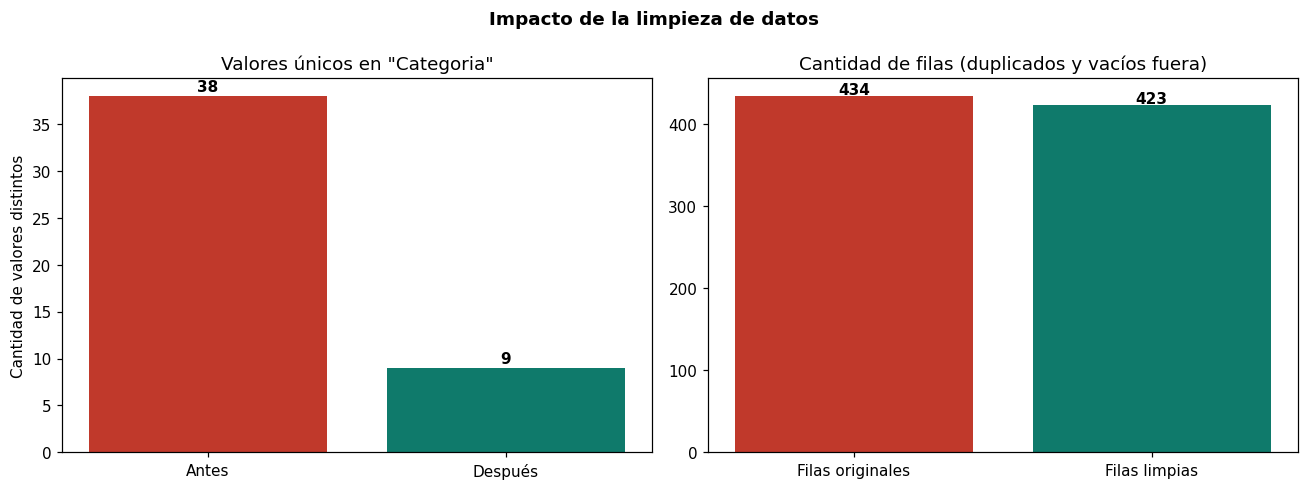

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(['Antes', 'Después'], [df_crudo['Categoria'].nunique(), df['Categoria'].nunique()],
            color=['#C0392B', '#0F7A6B'])
axes[0].set_title('Valores únicos en "Categoria"')
axes[0].set_ylabel('Cantidad de valores distintos')
for i, v in enumerate([df_crudo['Categoria'].nunique(), df['Categoria'].nunique()]):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

axes[1].bar(['Filas originales', 'Filas limpias'], [len(df_crudo), len(df)],
            color=['#C0392B', '#0F7A6B'])
axes[1].set_title('Cantidad de filas (duplicados y vacíos fuera)')
for i, v in enumerate([len(df_crudo), len(df)]):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.suptitle('Impacto de la limpieza de datos', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 3.1) Ahora sí se pueden responder preguntas de negocio

Con los datos ya numéricos y estandarizados, algo tan simple como "¿en qué gastamos más?" — imposible de calcular de forma confiable con los datos crudos — toma una línea de código.

Categoria
Arriendo             $43.931.304
Marketing            $11.818.386
Capacitación         $11.422.925
Servicios Básicos     $8.243.204
Software              $4.781.541
Otros                 $3.690.733
Oficina               $3.108.157
Transporte            $1.856.214
Sin Categoría         $1.679.844
Name: Monto, dtype: str


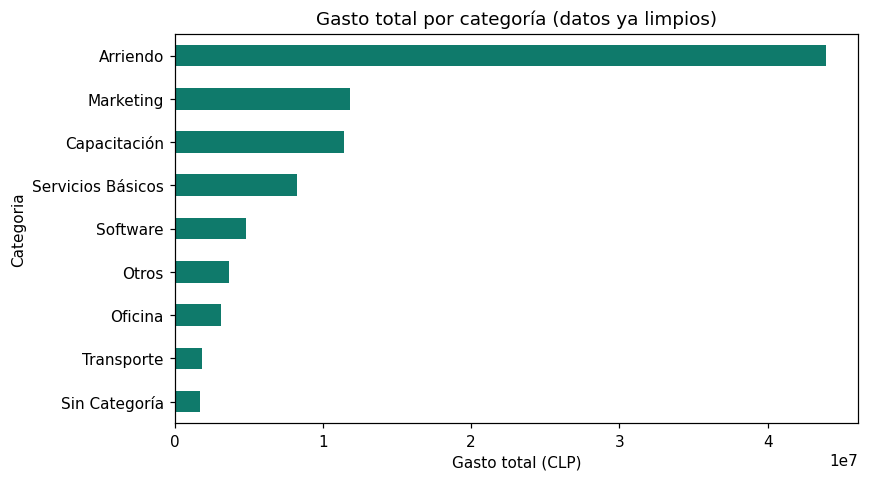

In [15]:
gasto_por_categoria = df[df['Monto'] > 0].groupby('Categoria')['Monto'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
gasto_por_categoria.plot(kind='barh', ax=ax, color='#0F7A6B')
ax.set_xlabel('Gasto total (CLP)')
ax.set_title('Gasto total por categoría (datos ya limpios)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(gasto_por_categoria.apply(lambda x: f'${x:,.0f}'.replace(',', '.')))


## 4) Exportación y empaquetado como herramienta reutilizable

Todo el pipeline anterior se empaquetó en `limpiar_gastos.py`, un script que un cliente puede ejecutar directamente desde línea de comandos sobre cualquier planilla nueva con esta misma estructura de columnas, sin necesidad de tocar el notebook:

```bash
python limpiar_gastos.py gastos_octubre.xlsx --salida gastos_octubre_limpio.xlsx --reporte reporte.txt
```

Esto es lo que convierte este análisis puntual en un **servicio repetible**: el cliente puede correr el script cada mes sobre su nueva planilla de gastos y obtener datos limpios más un reporte de trazabilidad, sin depender de que alguien lo limpie manualmente cada vez.

In [ ]:
from limpiar_gastos import limpiar_dataframe, formatear_reporte

df_final, reporte = limpiar_dataframe(
    df_crudo,
    categorias=CATEGORIAS_POR_DEFECTO,
    metodos_pago=METODOS_PAGO_POR_DEFECTO,
)
print(formatear_reporte(reporte))

df_final.to_excel('gastos_pyme_limpio.xlsx', index=False, sheet_name='Gastos Limpios')
print('\nArchivo limpio exportado: gastos_pyme_limpio.xlsx')


## 5) Conclusiones

- Se diagnosticaron y corrigieron 7 tipos de problema de calidad de datos distintos (formatos de fecha, formatos de monto, categorías inconsistentes, métodos de pago inconsistentes, valores booleanos sin estandarizar, duplicados y valores nulos), pasando de 434 filas crudas a 423 filas limpias y confiables.
- El pipeline de limpieza se diseñó basado en **catálogos de valores canónicos** en vez de reglas de reemplazo puntuales — esto significa que si aparece una nueva variante de categoría el mes siguiente, basta con agregar una línea al diccionario en vez de reescribir la lógica.
- El resultado no es solo un dataset limpio, sino una **herramienta reutilizable** (`limpiar_gastos.py`) que un cliente puede ejecutar directamente sobre sus futuras planillas de gastos, con un reporte automático de trazabilidad de lo corregido.
- **Próximos pasos posibles:** conectar este pipeline a un dashboard de Power BI actualizado automáticamente, o extender el catálogo de categorías/proveedores para que se ajuste a la nomenclatura real de un cliente específico.